In [2]:
# import packages and load data in
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

year_and_month = ['202511','202512','202601', '202602', '202603', '202604', '202605']
CRMLSSold_data = pd.DataFrame()

for year_month in year_and_month:
    # Load the data for each year and month
    data = pd.read_csv(f'data/CRMLSSold{year_month}.csv')
    # Append the data to the main DataFrame
    CRMLSSold_data = pd.concat([CRMLSSold_data, data], ignore_index=True)



display(CRMLSSold_data.head(10))
CRMLSSold_data.info()




/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_27971/2941833373.py:12: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(f'data/CRMLSSold{year_month}.csv')


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,NaN,5913.0,3.0,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,NaN,18432.0,NaN,False,2.0,Other,95124,NaN,18432.0,NaN
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,NaN,5300.0,0.0,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,NaN,5272.0,1.0,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,NaN,10500.0,3.0,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN
5,LakeCounty,LakeCounty,Vinyl,True,NaN,NaN,False,325000.0,1147188566,sarahdhomes4sale@gmail.com,...,NaN,36590.0,3.0,False,2.0,Konocti Unified,95423,0.0,36590.0,NaN
6,SanDiego,SanDiego,Laminate,False,NaN,NaN,False,2000.0,1147186360,raymond.erni@gmail.com,...,NaN,NaN,NaN,NaN,0.0,NaN,91977,0.0,NaN,NaN
7,PacificWest,PacificWest,NaN,True,NaN,NaN,True,985000.0,1147186097,kari@thedelaneyteam.com,...,NaN,7200.0,4.0,False,2.0,Tustin Unified,92780,0.0,7200.0,NaN
8,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,530000.0,1147179644,mhilliard@navigaterealestate.org,...,NaN,8276.0,NaN,False,0.0,NaN,95965,NaN,8276.0,NaN
9,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,False,NaN,NaN,False,1700000.0,1147177566,laura@themorenogroupla.com,...,50x148,7377.0,NaN,False,NaN,NaN,90025,NaN,7377.0,NaN


<class 'pandas.DataFrame'>
RangeIndex: 143492 entries, 0 to 143491
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 137427 non-null  str    
 1   ListAgentAOR                  143438 non-null  str    
 2   Flooring                      83650 non-null   str    
 3   ViewYN                        129338 non-null  object 
 4   WaterfrontYN                  86 non-null      object 
 5   BasementYN                    2330 non-null    object 
 6   PoolPrivateYN                 127746 non-null  object 
 7   OriginalListPrice             143088 non-null  float64
 8   ListingKey                    143492 non-null  int64  
 9   ListAgentEmail                143162 non-null  str    
 10  CloseDate                     143492 non-null  str    
 11  ClosePrice                    143491 non-null  float64
 12  ListAgentFirstName            142899 non-null  str    


In [3]:
# Restrict analysis to PropertyType = 'Residential' and PropertySubType = SingleFamilyResidence
CRMLSSold_data = CRMLSSold_data[
    (CRMLSSold_data['PropertyType'] == 'Residential') &
    (CRMLSSold_data['PropertySubType'] == 'SingleFamilyResidence')
]


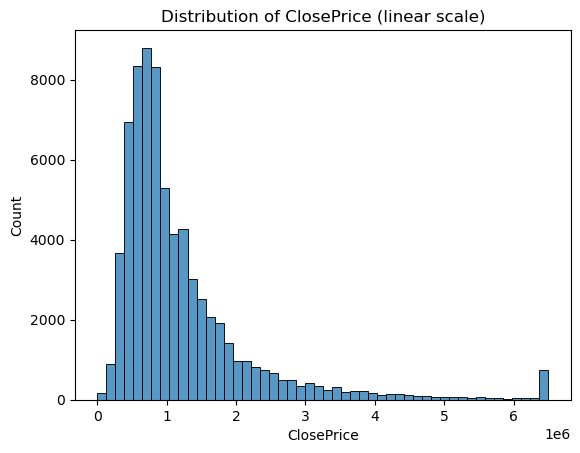

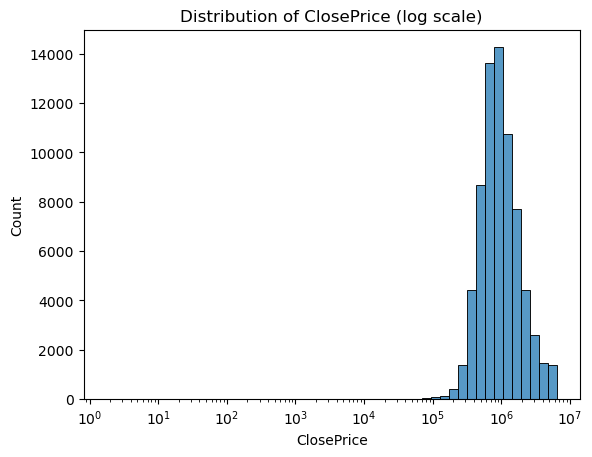

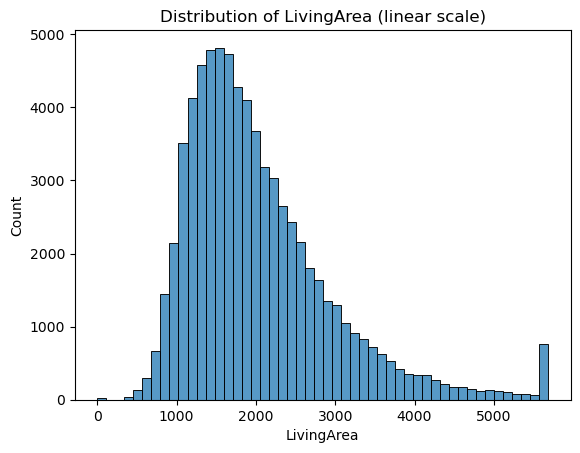

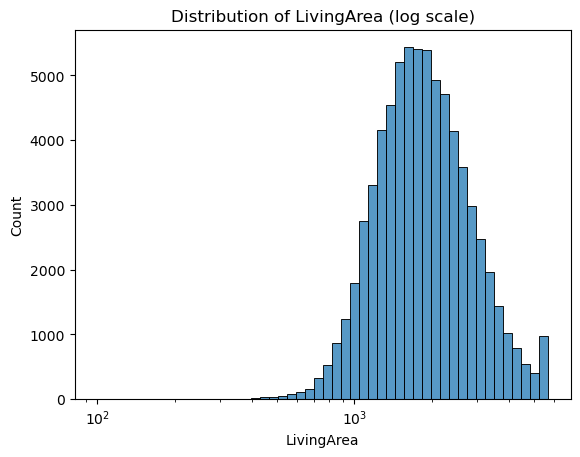

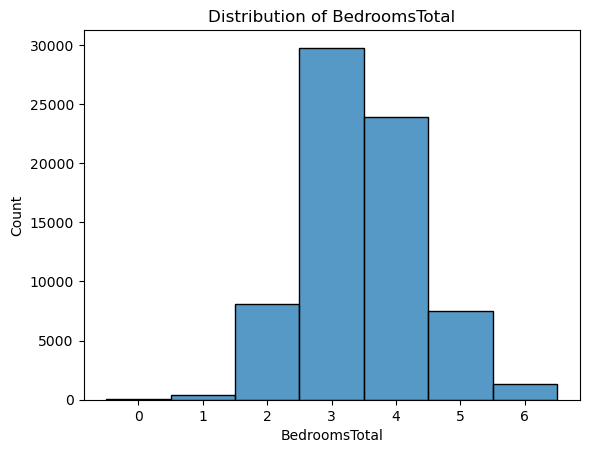

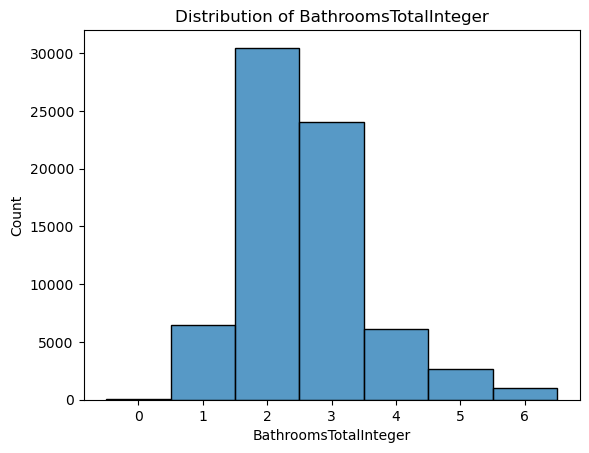

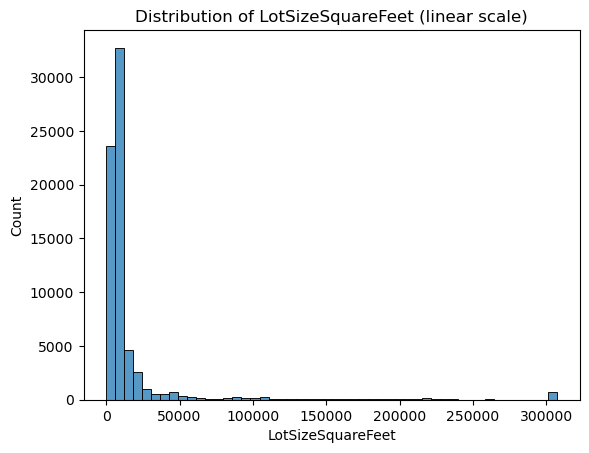

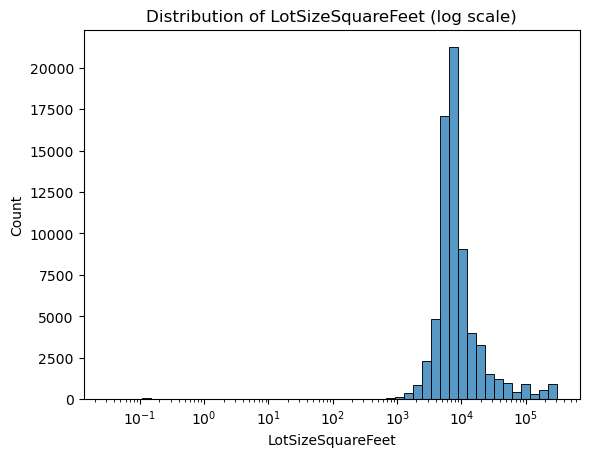

In [4]:
"""
# explore distributions of ClosePrice, LivingArea, Bedrooms, Bathrooms, and LotSize

we clip at the 99th percentile because a small number of extreme outliers as they 
stretch the x-axis so much that the rest of the distribution gets squashed into a single bar

we also plot on a log scale because even after clipping, these variables are still
heavily right-skewed  so a linear x-axis helps visualize the data more effectively.
"""
# ClosePrice: right-skewed, wide range
data = CRMLSSold_data['ClosePrice'].dropna()
data = data.clip(upper=data.quantile(0.99))
sns.histplot(data, bins=50)
plt.title('Distribution of ClosePrice (linear scale)')
plt.show()

sns.histplot(data, log_scale=True, bins=50)
plt.title('Distribution of ClosePrice (log scale)')
plt.show()

# LivingArea: right-skewed, continuous
data = CRMLSSold_data['LivingArea'].dropna()
data = data.clip(upper=data.quantile(0.99))
sns.histplot(data, bins=50)
plt.title('Distribution of LivingArea (linear scale)')
plt.show()

sns.histplot(data, log_scale=True, bins=50)
plt.title('Distribution of LivingArea (log scale)')
plt.show()

# BedroomsTotal: small integer counts -> discrete bins, no log scale needed
data = CRMLSSold_data['BedroomsTotal'].dropna()
data = data[data <= data.quantile(0.99)]
sns.histplot(data, discrete=True)
plt.title('Distribution of BedroomsTotal')
plt.show()

# BathroomsTotalInteger: small integer counts -> discrete bins, no log scale needed
data = CRMLSSold_data['BathroomsTotalInteger'].dropna()
data = data[data <= data.quantile(0.99)]
sns.histplot(data, discrete=True)
plt.title('Distribution of BathroomsTotalInteger')
plt.show()

# LotSizeSquareFeet: heavily right-skewed, large range
data = CRMLSSold_data['LotSizeSquareFeet'].dropna()
data = data[data > 0].clip(upper=data.quantile(0.99))
sns.histplot(data, bins=50)
plt.title('Distribution of LotSizeSquareFeet (linear scale)')
plt.show()

sns.histplot(data, log_scale=True, bins=50)
plt.title('Distribution of LotSizeSquareFeet (log scale)')
plt.show()

### Notes on outlier clipping and log scaling

- **Removing outliers (clipping at the 99th percentile):** A handful of extreme listings (e.g. multi-million dollar homes, huge lots) stretch the x-axis so much that the rest of the distribution gets compressed into a single bar. Clipping at the 99th percentile keeps these rare extreme values from dominating the plot while preserving the overall shape of the distribution.
- **Why log scale:** Even after clipping, variables like `ClosePrice`, `LivingArea`, and `LotSizeSquareFeet` are still heavily right-skewed — most values are clustered at the lower end with a long tail of larger values. A log scale spreads out the clustered low values and compresses the tail, making the underlying shape of the distribution much easier to see.
- **What we found:** On a linear scale, these variables looked like a single tall spike near zero with almost nothing visible elsewhere. On a log scale, the distributions revealed a roughly unimodal, near-normal (bell-shaped) pattern, suggesting these variables are closer to log-normally distributed rather than just "skewed and messy."
